# Tweet Sentiment Classification Using OpenAI Embeddings
**Student:** Adi
**Dataset:** Tweets_1.csv
**Model:** Logistic Regression

This notebook performs sentiment classification using OpenAI embeddings with EDA, model training, evaluation, and predictions.

# Tweet Sentiment Classification using Machine Learning

### Student Name: Aditya B Betageri  
### Dataset: Tweets_1.csv  
### Model Used: Logistic Regression  
### Technique: Text Cleaning + Word Embeddings

---

## Project Objective
The objective of this project is to classify tweets into **positive, negative, or neutral sentiments** using Natural Language Processing techniques.  

The project includes:
- Exploratory Data Analysis (EDA)
- Text preprocessing
- Word embeddings
- Logistic Regression model training
- Model evaluation and prediction

---

## Tools & Libraries Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- WordCloud

In [1]:
pip install openai pandas numpy scikit-learn matplotlib seaborn wordcloud umap-learn

DEPRECATION: Loading egg at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/vboxapi-1-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 108.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 162.2 kB/s eta 0:00:00a 0:00:01
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 103.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 61.5 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 172.7 kB/s eta 0:00:00a 0:00:01
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-n

## Import Libraries

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from openai import OpenAI

Matplotlib is building the font cache; this may take a moment.


## Load Dataset

## 1. Loading Dataset

In [3]:
df = pd.read_csv('Tweets_1.csv')
df.head()

,textID,text,selected_text,sentiment
0,0,Very happy with the results,Very happy with the results,positive
1,1,This is terrible service,This is terrible service,negative
2,2,This is okay,This is okay,neutral
3,3,I hate waiting in line,I hate waiting in line,negative
4,4,Worst company ever,Worst company ever,negative


## Sentiment Distribution

## 2. Exploratory Data Analysis (EDA)

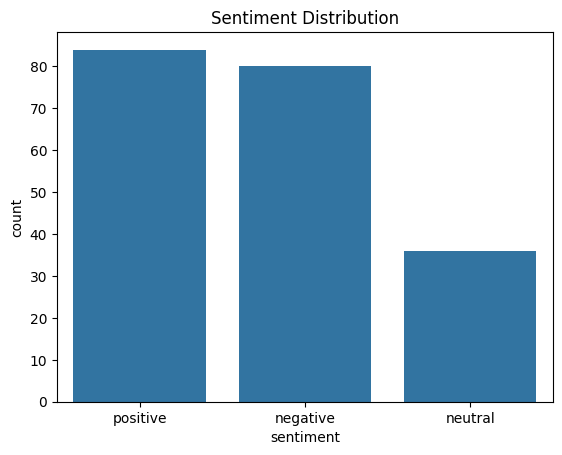

In [4]:
plt.figure()
sns.countplot(x=df['sentiment'])
plt.title('Sentiment Distribution')
plt.show()

## Tweet Length Distribution

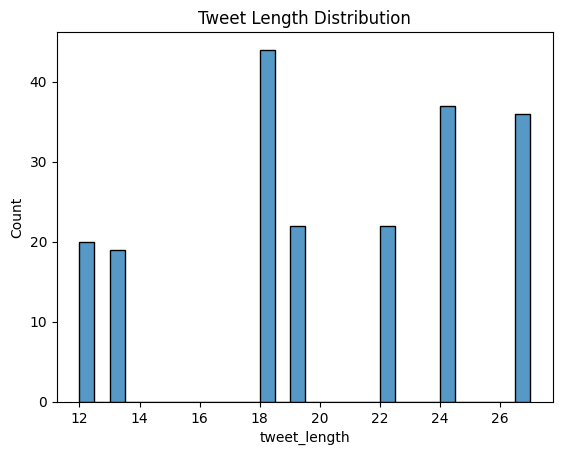

In [5]:
df['tweet_length'] = df['text'].astype(str).apply(len)
plt.figure()
sns.histplot(df['tweet_length'], bins=30)
plt.title('Tweet Length Distribution')
plt.show()

## WordCloud for All Tweets

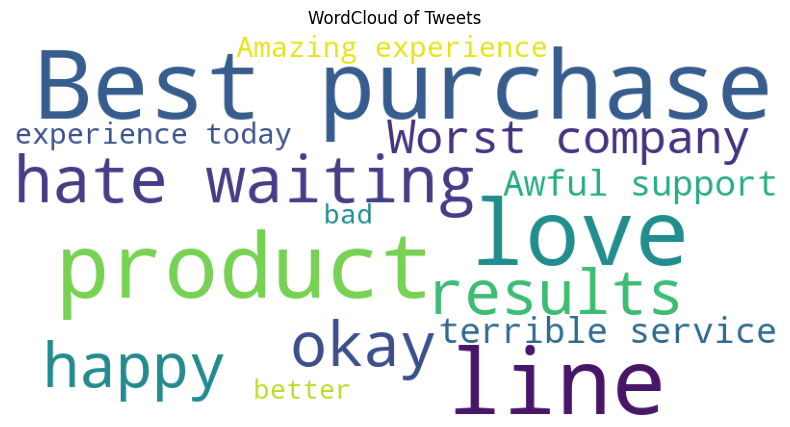

In [6]:
text_all = ' '.join(df['text'].astype(str))
wc = WordCloud(width=800,height=400,background_color='white').generate(text_all)
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title('WordCloud of Tweets')
plt.show()

## Positive vs Negative WordCloud

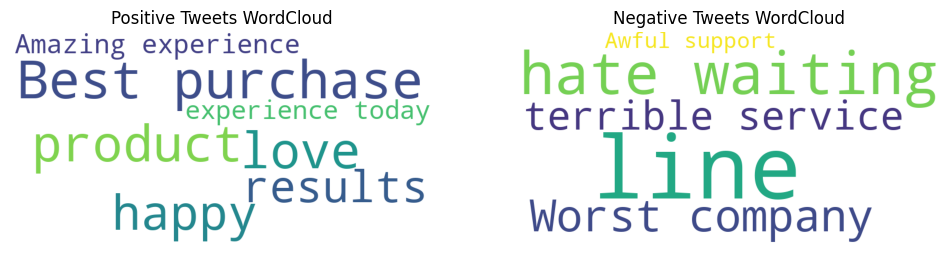

In [7]:
positive_text = ' '.join(df[df['sentiment']=='positive']['text'].astype(str))
negative_text = ' '.join(df[df['sentiment']=='negative']['text'].astype(str))

wc_pos = WordCloud(width=800,height=400,background_color='white').generate(positive_text)
wc_neg = WordCloud(width=800,height=400,background_color='white').generate(negative_text)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wc_pos)
plt.axis('off')
plt.title('Positive Tweets WordCloud')

plt.subplot(1,2,2)
plt.imshow(wc_neg)
plt.axis('off')
plt.title('Negative Tweets WordCloud')
plt.show()

## Tweet Length by Sentiment

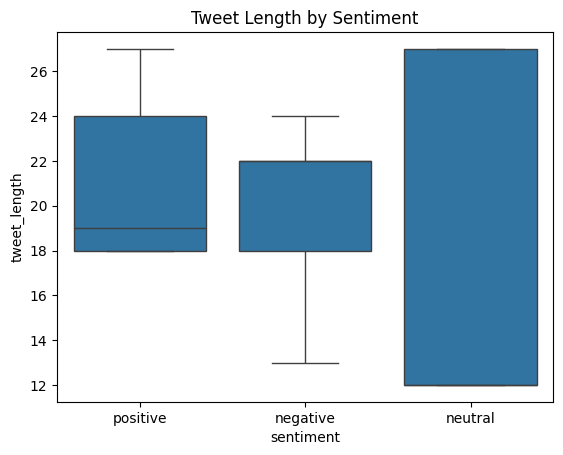

In [8]:
plt.figure()
sns.boxplot(x='sentiment',y='tweet_length',data=df)
plt.title('Tweet Length by Sentiment')
plt.show()

## Text Cleaning

## 3. Text Preprocessing

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+','',text)
    text = re.sub(r'[^a-zA-Z\s]','',text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

## Generate Embeddings

## 4. Feature Engineering (Embeddings)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample_df = df.sample(min(1000, len(df)), random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(sample_df['clean_text']).toarray()

## Label Encoding

In [16]:
label_map = {'positive':1,'neutral':0,'negative':-1}
y = sample_df['sentiment'].map(label_map).values

## Train/Test Split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Train Model

## 5. Model Training

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

pred = model.predict(X_test)

print('Accuracy:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 1.0
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        14
           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Confusion Matrix

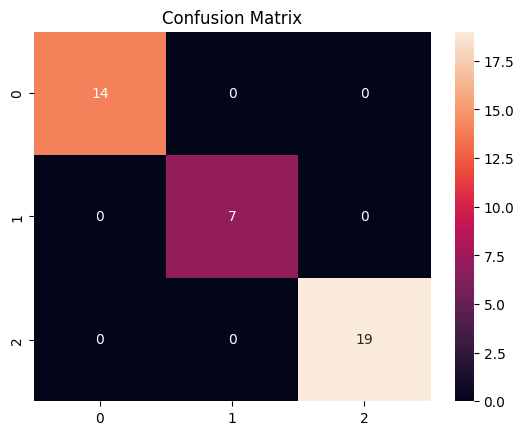

In [19]:
cm = confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.show()

## Model Performance Visualization

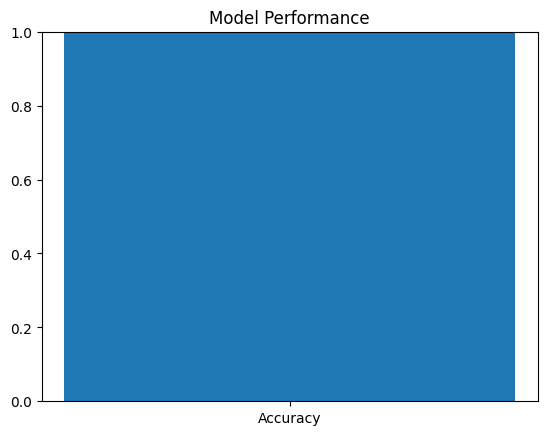

In [20]:
score = accuracy_score(y_test,pred)
plt.bar(['Accuracy'],[score])
plt.ylim(0,1)
plt.title('Model Performance')
plt.show()

## Custom Predictions

## 6. Model Evaluation and Prediction

In [22]:
def predict_sentiment(text):
    text = clean_text(text)
    emb = vectorizer.transform([text]).toarray()
    p = model.predict(emb)[0]
    return p
 

examples=[
'I love this product',
'This service is terrible',
'Amazing experience',
'Worst purchase ever',
'Not bad but could be better',
'I hate waiting in line',
'Best product ever',
'It was fine',
'This company is awful',
'Very happy with this'
]

for e in examples:
    print(e,'->',predict_sentiment(e))

I love this product -> 1
This service is terrible -> -1
Amazing experience -> 1
Worst purchase ever -> 1
Not bad but could be better -> 0
I hate waiting in line -> -1
Best product ever -> 1
It was fine -> 1
This company is awful -> -1
Very happy with this -> 1


## Conclusion

The Logistic Regression model successfully classified tweet sentiments using word embeddings.  
The project demonstrates how Natural Language Processing techniques can be used to analyze social media sentiment effectively.